In [42]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , precision_score
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.linear_model import LassoCV
import numpy as np
import matplotlib.pyplot as plt

In [2]:
employee_df = pd.read_csv("employee_turnover.csv")

In [20]:
employee_df.head()
employee_df.isnull().sum()

Job_Satisfaction                           0
Performance_Rating                         0
Years_At_Company                           0
Work_Life_Balance                          0
Distance_From_Home                         0
Monthly_Income                             0
Education_Level                            0
Age                                        0
Num_Companies_Worked                       0
Employee_Role                              0
Annual_Bonus                               0
Training_Hours                             0
Department                                 0
Annual_Bonus_Squared                       0
Annual_Bonus_Training_Hours_Interaction    0
Employee_Turnover                          0
dtype: int64

<Axes: xlabel='Job_Satisfaction', ylabel='Employee_Turnover'>

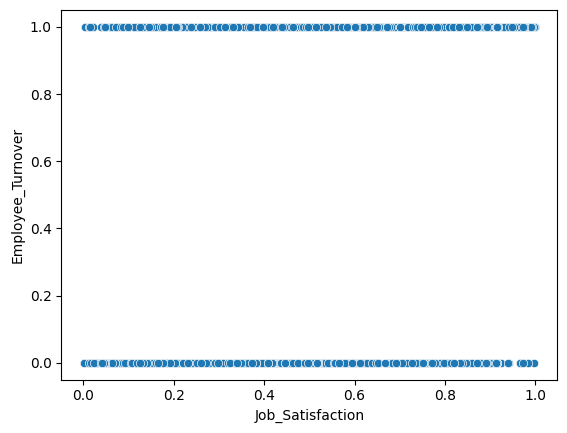

In [6]:
sns.scatterplot(x = employee_df["Job_Satisfaction"] , y = employee_df["Employee_Turnover"])

In [8]:
X = employee_df.drop(columns = ["Employee_Turnover"])
Y = employee_df["Employee_Turnover"]

In [9]:
X

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,0.914733,0.965914,0.147215,0.686677,0.251346,0.572003,0.089679,0.127247,0.125553,0.346950,0.450783,0.754675,0.905320,0.203205,0.340194
1346,0.396906,0.182952,0.877941,0.824077,0.774960,0.057290,0.556719,0.235014,0.119685,0.781613,0.211581,0.500812,0.526096,0.044767,0.105962
1347,0.099171,0.363498,0.849120,0.462270,0.763922,0.585370,0.975760,0.557090,0.782690,0.384706,0.449095,0.270280,0.253656,0.201686,0.121381
1348,0.048193,0.453892,0.640611,0.335230,0.952724,0.638797,0.993664,0.801292,0.510281,0.164325,0.649934,0.151225,0.405705,0.422414,0.098286


In [10]:
Y

0       0
1       0
2       1
3       0
4       0
       ..
1345    1
1346    1
1347    1
1348    1
1349    0
Name: Employee_Turnover, Length: 1350, dtype: int64

In [11]:
X_train , X_test , Y_train , Y_test = train_test_split(
    X , Y , test_size = 0.2, random_state = 42
)

In [14]:
Y_train[Y_train == 0]

755     0
109     0
1040    0
774     0
983     0
       ..
330     0
1238    0
466     0
121     0
1044    0
Name: Employee_Turnover, Length: 533, dtype: int64

In [15]:
Y_train[Y_train == 1]

548     1
1342    1
1203    1
573     1
1295    1
       ..
1095    1
1130    1
1294    1
860     1
1126    1
Name: Employee_Turnover, Length: 547, dtype: int64

In [28]:
lr = LogisticRegression()
lr.fit(X_train , Y_train)

LogisticRegression()

In [19]:
print(f"accuracy of model : {accuracy_score(Y_test , Y_pred) * 100} %")
print(f"precision of model : {precision_score(Y_test , Y_pred) * 100} %")

accuracy of model : 85.92592592592592 %
precision of model : 87.17948717948718 %


In [26]:
lasso = LogisticRegression(penalty = 'l1' , solver = 'liblinear' , C = 0.5)
lasso.fit(X_train , Y_train)

LogisticRegression(C=0.5, penalty='l1', solver='liblinear')

In [27]:
ridge = LogisticRegression(penalty = 'l2' , solver = 'liblinear' , C = 1 , max_iter = 200)
ridge.fit(X_train , Y_train)

LogisticRegression(C=1, max_iter=200, solver='liblinear')

In [32]:
models = {'Baseline' : lr , 'Lasso' : lasso , 'Ridge' : ridge}

In [35]:
normal_model = models['Baseline']
lasso_model = models['Lasso']
ridge_model = models['Ridge']

In [37]:
y_predict_baseline = normal_model.predict(X_test)
y_predict_lasso = lasso_model.predict(X_test)
y_predict_ridge =ridge_model.predict(X_test)

AttributeError: module 'matplotlib.pyplot' has no attribute 'set_xticklabels'

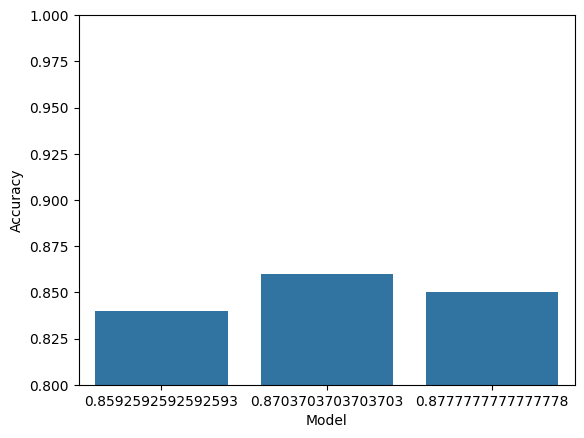

In [48]:


x = [accuracy_score(Y_test , y_predict_baseline) , 
     accuracy_score(Y_test , y_predict_lasso),
     accuracy_score(Y_test , y_predict_ridge)
    ]
y = [0.84 , 0.86 , 0.85]

sns.barplot(
    x = x,
    y = y
)
plt.ylim(0.8, 1.0)        # OPTIONAL: zoom y-axis
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()